In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

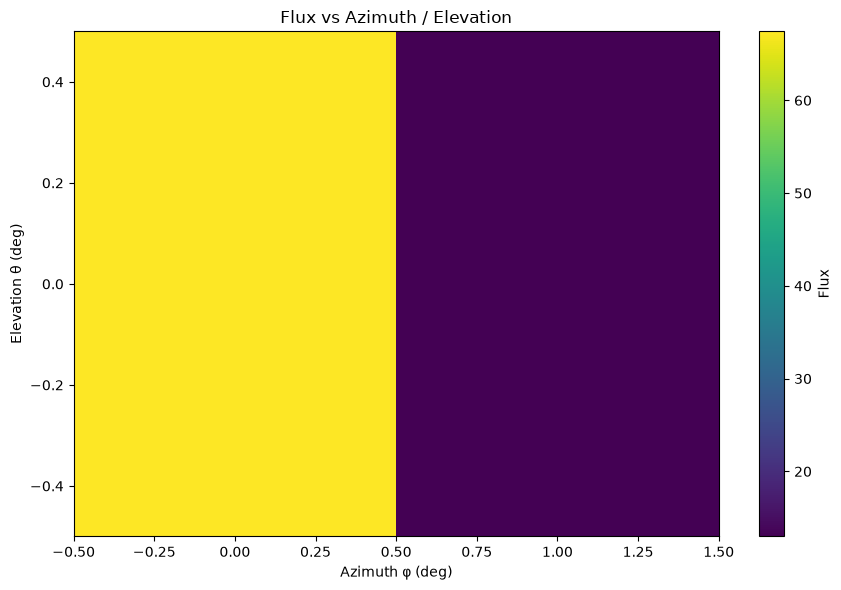

In [ ]:
# --- Load data ---
# Columns: azimuth (phi), elevation (theta), flux, std (ignored), n_events (ignored)
#filename = "/Users/dorageeraerts/Documents/PhD/simulation/Muraves/Simulation_Studies/PUMAS-and-TURTLE/Mulder/mulder_output/flux_all_bins_phi150-210_el0.-40._dphi0.2_del0.2_rho2.65E3_nE10000_nEvents100.txt" 
filename = "/Users/dorageeraerts/Documents/PhD/simulation/Muraves/Simulation_Studies/PUMAS-and-TURTLE/Mulder/test/transmission_5m_1.0bin_rho2650.0_test_transmission.txt"
df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["phi", "theta", "flux", "std", "n_jobs", "n_events"],
)

# Put each point into a 1-degree bin
df["phi_bin"] = np.floor(df["phi"])
df["theta_bin"] = np.floor(df["theta"])

# Average the flux in each 1°×1° bin
df_deg = (
    df.groupby(["theta_bin", "phi_bin"], as_index=False)["flux"]
      .mean()
)

'''# group in bins of 1x1 degree, keep bins centered on the degree: use round()
df["phi_bin"] = df["phi"].round()
df["theta_bin"] = df["theta"].round()

df_deg = (
    df.groupby(["theta_bin", "phi_bin"], as_index=False)["flux"]
      .mean()
)'''

# Create grid
grid = df_deg.pivot(
    index="theta_bin",
    columns="phi_bin",
    values="flux"
)

# --- Pivot into a 2D grid: rows = theta, cols = phi ---
#grid = df.pivot(index="theta", columns="phi", values="flux")

phi_vals = grid.columns.values      # x-axis
theta_vals = grid.index.values      # y-axis
flux_grid = grid.values             # 2D array, shape (n_theta, n_phi)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

# pcolormesh needs bin edges, not centers, for correct cell placement.
# If your phi/theta values are on a regular 1-degree grid, this adds
# half-a-bin padding on each side so cells are centered on their values.
def edges_from_centers(centers):
    centers = np.sort(centers)
    step = np.diff(centers).mean() if len(centers) > 1 else 1.0
    return np.concatenate([centers - step / 2, [centers[-1] + step / 2]])

phi_edges = edges_from_centers(phi_vals)
theta_edges = edges_from_centers(theta_vals)

mesh = ax.pcolormesh(
    phi_edges, theta_edges, flux_grid,
    shading="flat", cmap="viridis"
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Flux")

ax.set_xlabel("Azimuth φ (deg)")
ax.set_ylabel("Elevation θ (deg)")
ax.set_title("Flux vs Azimuth / Elevation")

plt.tight_layout()
plt.savefig("flux_map.png", dpi=200)
plt.show()

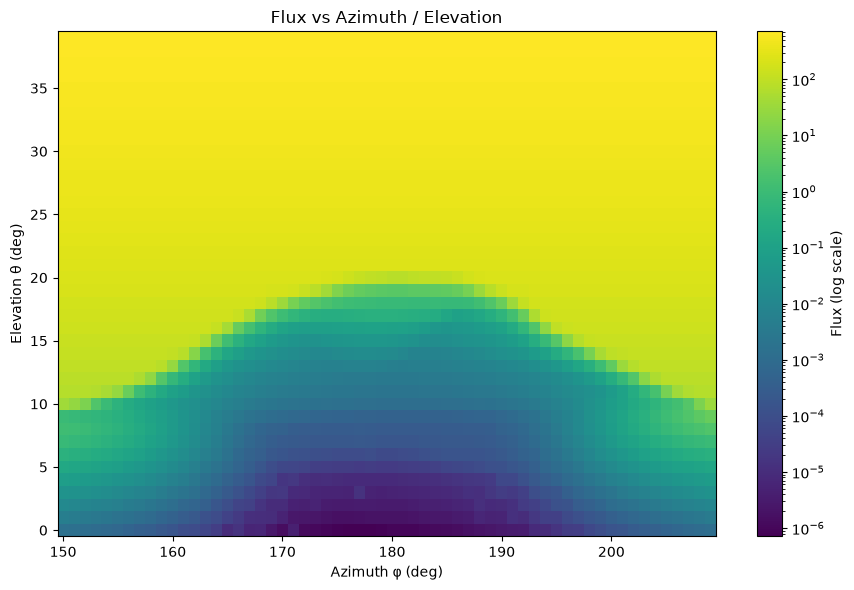

In [5]:
from matplotlib.colors import LogNorm

# Avoid zeros because LogNorm cannot display them
flux_grid_log = np.where(flux_grid > 0, flux_grid, np.nan)

fig, ax = plt.subplots(figsize=(9, 6))

mesh = ax.pcolormesh(
    phi_edges,
    theta_edges,
    flux_grid_log,
    shading="flat",
    cmap="viridis",
    norm=LogNorm()
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label("Flux (log scale)")


ax.set_xlabel("Azimuth φ (deg)")
ax.set_ylabel("Elevation θ (deg)")
ax.set_title("Flux vs Azimuth / Elevation")

plt.tight_layout()
#plt.savefig("flux_map.png", dpi=200)
plt.show()

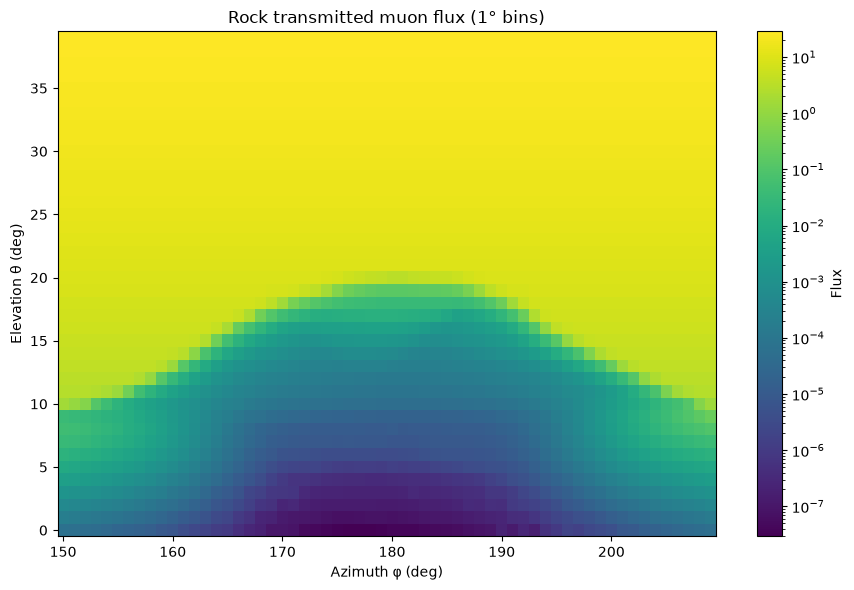

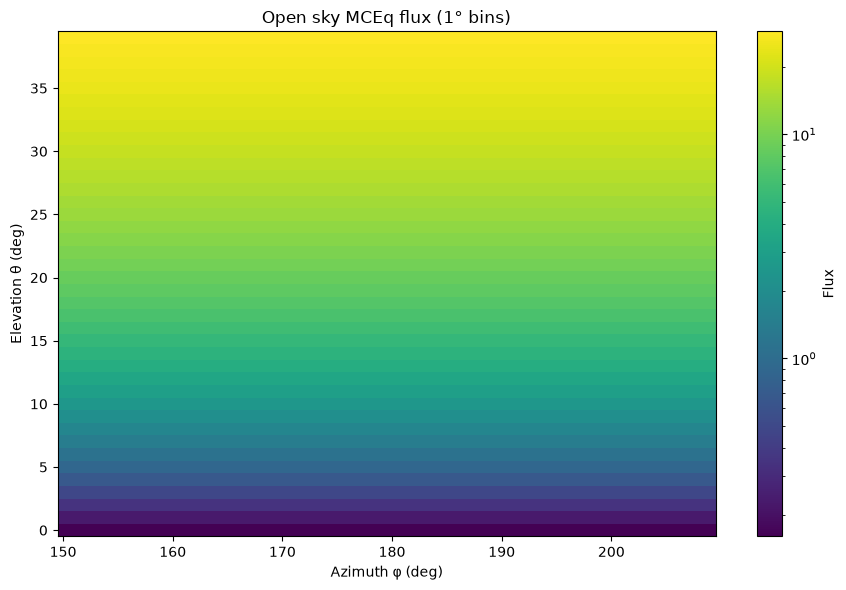

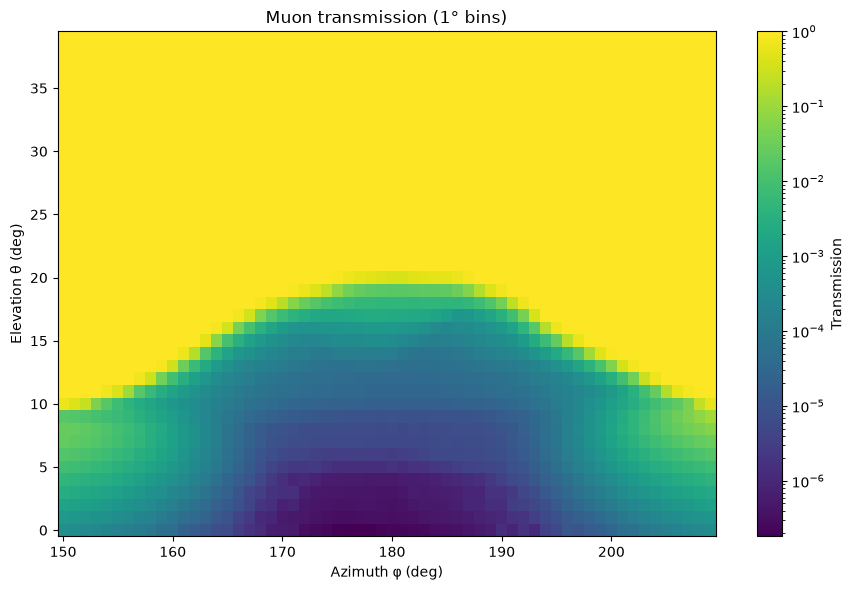

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# ==========================================================
# Load Mulder transmission output
# Columns:
# azimuth elevation phi_rock phi_rock_err phi_open
# transmission transmission_err N_events
# ==========================================================

filename = (
    "/Users/dorageeraerts/Documents/PhD/simulation/Muraves/Simulation_Studies/PUMAS-and-TURTLE/Mulder/mulder_output/flux_all_bins_phi150-210_el0.-40._dphi0.2_del0.2_rho2.65E3_nE10000_nEvents100.txt"
)


df = pd.read_csv(
    filename,
    sep=r"\s+",
    comment="#",
    header=None,
    names=[
        "phi",
        "theta",
        "phi_rock",
        "phi_rock_err",
        "phi_open",
        "transmission",
        "transmission_err",
        "n_events",
    ],
)


# ==========================================================
# Rebin 0.2 degree bins -> 1 degree bins
# ==========================================================

df["phi_bin"] = np.floor(df["phi"])
df["theta_bin"] = np.floor(df["theta"])


df_deg = (
    df.groupby(
        ["theta_bin", "phi_bin"],
        as_index=False
    )
    .agg(
        {
            "phi_rock": "mean",
            "phi_open": "mean",

            # independent uncertainties
            "phi_rock_err":
                lambda x: np.sqrt(np.sum(x**2)),

            "phi_open":
                "mean",
        }
    )
)


# recompute transmission AFTER summing fluxes

df_deg["transmission"] = (
    df_deg["phi_rock"]
    /
    df_deg["phi_open"]
)


df_deg["transmission_err"] = (
    df_deg["phi_rock_err"]
    /
    df_deg["phi_open"]
)


# ==========================================================
# Plot helper
# ==========================================================

def plot_map(df, column, title, label, filename, cmap="viridis"):

    grid = df.pivot(
        index="theta_bin",
        columns="phi_bin",
        values=column
    )


    phi_vals = grid.columns.values
    theta_vals = grid.index.values
    values = grid.values


    def edges_from_centers(values):

        values = np.sort(values)

        if len(values) > 1:
            step = np.mean(np.diff(values))
        else:
            step = 1.0

        return np.concatenate(
            [
                values - step/2,
                [values[-1] + step/2]
            ]
        )


    phi_edges = edges_from_centers(phi_vals)
    theta_edges = edges_from_centers(theta_vals)


    fig, ax = plt.subplots(
        figsize=(9,6)
    )


    mesh = ax.pcolormesh(
        phi_edges,
        theta_edges,
        values,
        shading="flat",
        cmap=cmap, norm=LogNorm()
    )


    cbar = fig.colorbar(
        mesh,
        ax=ax
    )

    cbar.set_label(label)


    ax.set_xlabel(
        "Azimuth φ (deg)"
    )

    ax.set_ylabel(
        "Elevation θ (deg)"
    )

    ax.set_title(title)


    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300
    )

    plt.show()



# ==========================================================
# Plot rock flux
# ==========================================================

plot_map(
    df_deg,
    "phi_rock",
    "Rock transmitted muon flux (1° bins)",
    "Flux",
    "rock_flux_1deg.png",
    cmap="viridis"
)


# ==========================================================
# Plot open sky flux
# ==========================================================

plot_map(
    df_deg,
    "phi_open",
    "Open sky MCEq flux (1° bins)",
    "Flux",
    "opensky_flux_1deg.png",
    cmap="viridis"
)


# ==========================================================
# Plot transmission
# ==========================================================

plot_map(
    df_deg,
    "transmission",
    "Muon transmission (1° bins)",
    "Transmission",
    "transmission_1deg.png",
    cmap="viridis"
)